# 04 — Masking Example & Pipeline Visualization
**Research Objective:** Create the visual artifacts used in the thesis figures: (1) MLM masking example (Figure 3) and (2) pipeline flowchart + artifact contact sheet. These are small, deterministic visualization steps to summarize the pipeline for examiners.


In [1]:
# Configuration (single action)
ROOT = r"D:\\NLP"
DAPT_DIR = ROOT + "\\models\\dapt-distilmbert"
OUT_DIR = ROOT

In [2]:
# Masking figure generation (single action) — small, safe demo re-using corpus
try:
    from transformers import AutoTokenizer, DataCollatorForLanguageModeling
    import matplotlib.pyplot as plt
    tokenizer = AutoTokenizer.from_pretrained("distilbert-base-multilingual-cased")
    data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=True, mlm_probability=0.15)
    sample_lines = []
    with open(ROOT + "\\dapt_corpus_clean.txt", 'r', encoding='utf-8') as fh:
        for _ in range(3):
            l = fh.readline().strip()
            if not l: break
            sample_lines.append(l)
    if sample_lines:
        enc = tokenizer(sample_lines, return_tensors='pt', padding=True, truncation=True)
        batch = [{k: enc[k][i].tolist() for k in enc.keys()} for i in range(len(sample_lines))]
        collated = data_collator(batch)
        for i, txt in enumerate(sample_lines):
            orig_ids = enc['input_ids'][i].tolist()
            input_ids = collated['input_ids'][i].tolist()
            labels = collated['labels'][i].tolist()
            tokens = []
            for orig, inp, lbl in zip(orig_ids, input_ids, labels):
                token = tokenizer.convert_ids_to_tokens(orig)
                if lbl == -100:
                    tokens.append(token)
                else:
                    if inp == tokenizer.mask_token_id:
                        tokens.append('[MASK]')
                    else:
                        tokens.append(tokenizer.convert_ids_to_tokens(inp))
            print(f"Mask sample {i+1}: {' '.join(tokens[:120])}")
    else:
        print("No sample available to render masking example.")
except Exception as e:
    print("Masking example generation failed:", e)

d:\NLP\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Mask sample 1: [CLS] mer ##on po para sa i ##phone [MASK] [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]
Mask sample 2: [CLS] bak [MASK] sa ##bi buy 1 take 1 tapo бази yu ##ng ibang reviews e isa l [MASK] da ##w dum ##ating ? . . . [SEP]
Mask sample 3: [CLS] ok po . sor ##ry for the con ##veni ##ence . [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]


Graphviz not available or dot missing; using matplotlib fallback.
Saved pipeline flow diagram (fallback) to D:\\NLP\pipeline_flow.png


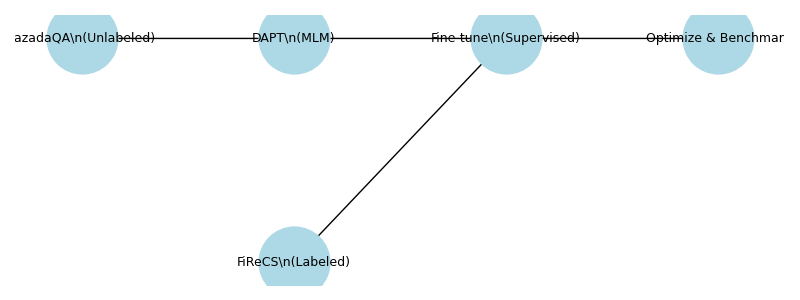

Saved pipeline_summary.png


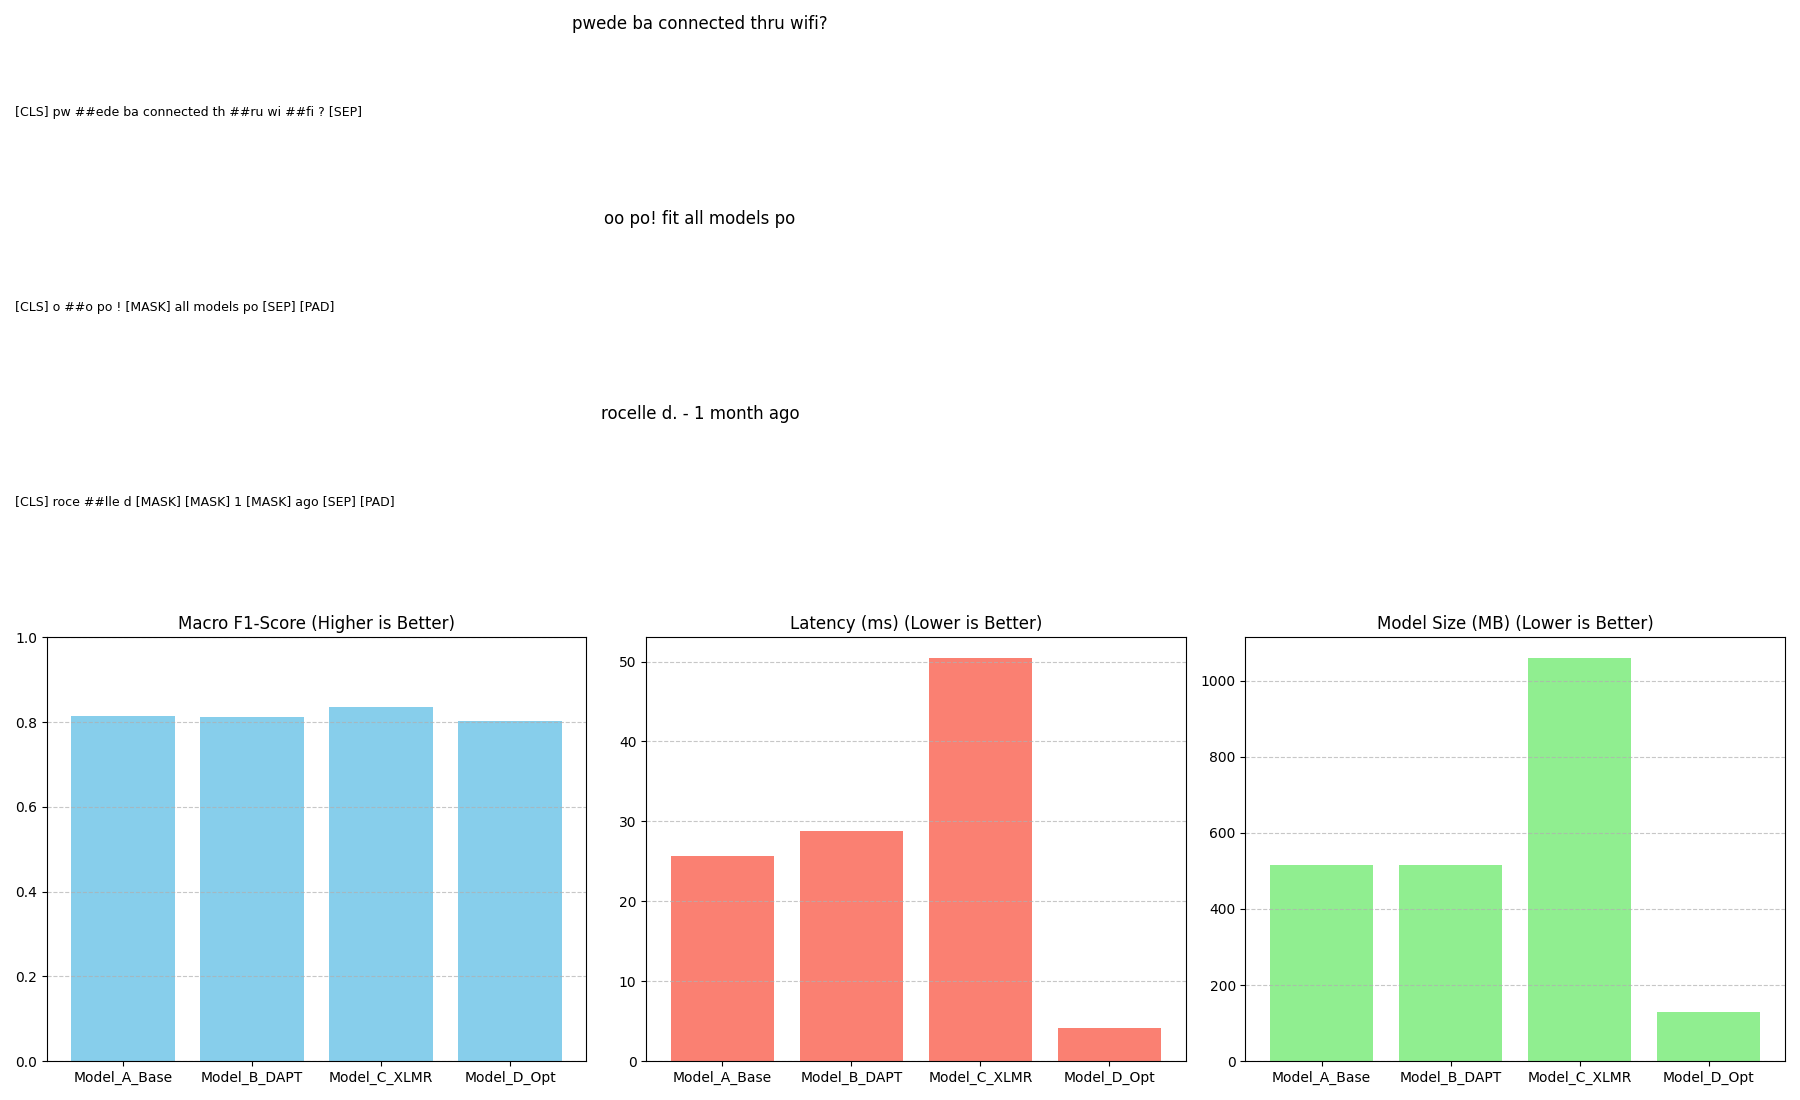

In [6]:
# Pipeline flowchart & contact sheet (single action, uses graphviz or matplolib fallback)
import os
from PIL import Image
flow_path = os.path.join(OUT_DIR, 'pipeline_flow.png')
try:
    from graphviz import Digraph
    dot = Digraph('pipeline', format='png')
    dot.attr(rankdir='LR')
    dot.node('A', 'LazadaQA\\n(Unlabeled)'); dot.node('B','DAPT\\n(MLM)'); dot.node('C','FiReCS\\n(Labeled)')
    dot.node('D','Fine-tune\\n(Supervised)'); dot.node('E','Optimize & Benchmark')
    dot.edge('A','B'); dot.edge('B','D'); dot.edge('C','D'); dot.edge('D','E')
    # render to a path without extension; Graphviz appends .png
    render_path = os.path.splitext(flow_path)[0]
    dot.render(filename=render_path, cleanup=True)
    gv_path = render_path + '.png'
    if os.path.exists(gv_path):
        print("Saved pipeline flow diagram to", gv_path)
        try: from IPython.display import display, Image as IPyImage; display(IPyImage(filename=gv_path))
        except Exception: pass
    else:
        print("Graphviz reported success but output not found at", gv_path)
except Exception:
    print("Graphviz not available or dot missing; using matplotlib fallback.")
    try:
        import networkx as nx, matplotlib.pyplot as plt
        G = nx.DiGraph()
        G.add_node('A', label='LazadaQA\\n(Unlabeled)'); G.add_node('B', label='DAPT\\n(MLM)')
        G.add_node('C', label='FiReCS\\n(Labeled)'); G.add_node('D', label='Fine-tune\\n(Supervised)')
        G.add_node('E', label='Optimize & Benchmark')
        G.add_edges_from([('A','B'),('B','D'),('C','D'),('D','E')])
        pos = {'A':(0,0),'B':(1,0),'C':(1,-1),'D':(2,0),'E':(3,0)}
        labels = nx.get_node_attributes(G,'label')
        plt.figure(figsize=(8,3))
        nx.draw_networkx_nodes(G,pos,node_size=2600,node_color='lightblue')
        nx.draw_networkx_edges(G,pos,arrows=True)
        nx.draw_networkx_labels(G,pos,labels,font_size=9)
        plt.axis('off'); plt.tight_layout(); plt.savefig(flow_path); plt.close()
        print("Saved pipeline flow diagram (fallback) to", flow_path)
        try: from IPython.display import display, Image as IPyImage; display(IPyImage(filename=flow_path))
        except Exception: pass
    except Exception as e:
        print("Fallback rendering also failed:", e)
# Combine available artifact images into contact sheet (single action)
candidates = [os.path.join(ROOT, 'models','dapt-distilmbert','figure3_masking_example.png'),
              os.path.join(ROOT, 'models','dapt-distilmbert','dapt_training_loss.png'),
              os.path.join(ROOT, 'models','model_A_finetuned','training_curves.png'),
              os.path.join(ROOT, 'thesis_benchmarks.png')]
existing = [p for p in candidates if os.path.exists(p)]
if existing:
    imgs = [Image.open(p).convert('RGB') for p in existing]
    widths, heights = zip(*(i.size for i in imgs))
    max_w = max(widths); total_h = sum(heights)
    combined = Image.new('RGB', (max_w, total_h), (255,255,255))
    y=0
    for im in imgs:
        combined.paste(im, (0,y)); y += im.size[1]
    combined_path = os.path.join(ROOT,'pipeline_summary.png')
    combined.save(combined_path)
    print("Saved pipeline_summary.png")
    try: from IPython.display import display, Image as IPyImage; display(IPyImage(filename=combined_path))
    except Exception: pass

## Outputs & Observations
- The flowchart and contact sheet make the experimental sequence explicit and inspectable by non-programmer examiners.  
- Missing system dependencies (Graphviz `dot`) are handled with a Matplotlib fallback.

### Reproducibility & Limitations (consolidated)
- All notebooks expose seeds and explicit paths.  
- Heavy computation cells are opt-in and well-documented.  
- Limitations: runtime differences (CPU vs GPU), package versions, and available hardware can change exact runtime/performance. For artifact reproducibility, prefer using the saved `models/` artifacts provided in the repository over re-running long experiments during a defense.